In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import streamlit as st
import joblib
import time

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [88]:
# load dataset
sales_data = pd.read_csv('sales_revenue_predictions.csv')
sales_data.drop(columns=['Unnamed: 1'],inplace=True)
# data explorations
sales_data.head(200)
sales_data.describe()
sales_data.sample(3000)
sales_data.index

RangeIndex(start=0, stop=3999, step=1)

In [89]:
# data cleaning 
sales_data.isnull().sum()
sales_data.dropna(inplace=True)
sales_data.duplicated().sum()
sales_data.drop_duplicates(inplace=True)

In [90]:
# sales encoding
sales_data = pd.get_dummies(sales_data,columns=['Season'],drop_first=True)
# define feature and target
X = sales_data.drop(columns=['Revenue'])
y = sales_data['Revenue']
# train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [91]:
# create and train model 
model = LinearRegression()
model.fit(X_train,y_train)
predictions = model.predict(X_test)
predictions

array([2.20155179e+09, 4.41033470e+08, 4.14947870e+09, 1.63689443e+09,
       1.70659443e+09, 1.17463749e+09, 5.81786661e+08, 7.47365533e+08,
       9.65141809e+08, 3.20704489e+09, 4.55809306e+09, 1.44895210e+09,
       1.37061779e+08, 1.25983807e+09, 3.74546471e+09, 7.70313689e+08,
       3.80074793e+09, 7.78157820e+08, 4.40825505e+09, 3.69539383e+09,
       3.32990680e+09, 1.88921278e+09, 1.23724669e+09, 4.57816151e+09,
       2.87914170e+09, 3.04721491e+09, 1.24736573e+09, 1.77378096e+09,
       2.35556777e+09, 3.10633962e+09, 9.13603866e+08, 3.91679470e+09,
       4.73913676e+09, 2.53862190e+09, 1.93928720e+09, 8.18657193e+08,
       1.10936725e+09, 2.79010292e+09, 5.30502411e+08, 4.62755607e+09,
       2.63167083e+08, 1.37844335e+09, 2.18437368e+09, 4.10241518e+08,
       1.62873105e+09, 4.11144383e+09, 4.31029211e+09, 4.81129866e+09,
       2.51696900e+09, 4.96635481e+09, 3.68864265e+09, 4.80753316e+09,
       3.75874388e+09, 1.56843663e+09, 2.16290658e+09, 4.00465097e+09,
      

In [46]:
# model evaulations
mse = mean_squared_error(y_test,predictions)
print('Mean Squared Error',mse)
score = r2_score(y_test,predictions)
print('Accuracy Score',score)

Mean Squared Error 0.06941273775152253
Accuracy Score 1.0


In [48]:
# checking model equations
print('Slope of (m):',model.coef_)
print('Intercept of (b):',model.intercept_)

Slope of (m): [ 3.50000003e-01  1.19999746e+02  8.49999999e+02  2.49999878e+00
  5.00000000e+04 -1.06003811e-03  1.88080338e-02  2.18318083e-02]
Intercept of (b): 0.02295064926147461


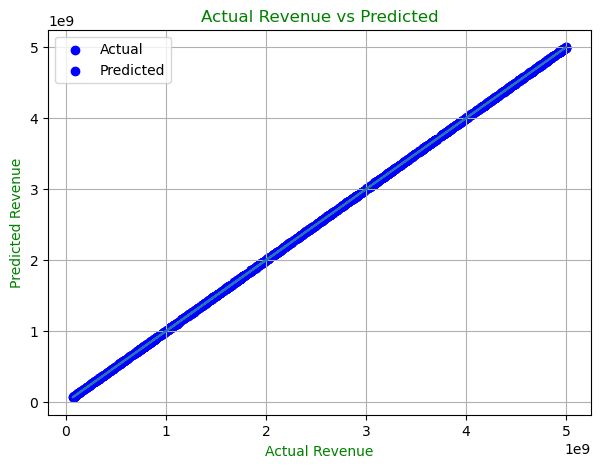

In [97]:
# graph visualisation
plt.figure(figsize=(7,5))
plt.scatter(y_test,predictions,label='Actual',c='b')
plt.scatter(y_test,predictions,label='Predicted',c='b')
plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         c='red')
plt.grid(True)
plt.legend(loc=False)
plt.title('Actual Revenue vs Predicted',c='g')
plt.xlabel('Actual Revenue',c='g')
plt.ylabel('Predicted Revenue',c='g')
plt.plot(y_test,predictions)
plt.show()

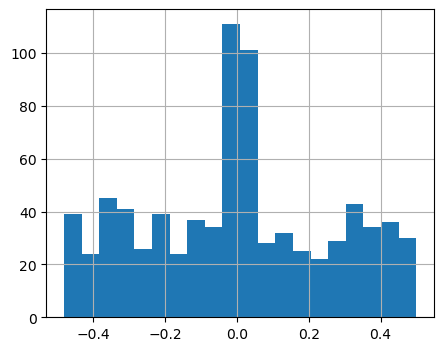

In [81]:
# error Distributions
plt.figure(figsize=(5,4))
error = y_test - predictions
plt.hist(error,bins=20)
plt.grid(True)
plt.show()

In [102]:
# save training columns
training_columns = X.columns

In [104]:
# new predictions
new_business = pd.DataFrame({

    'Advertising_Budget':[500000],

    'Employees':[15],

    'Store_Size':[2500],

    'Customer_Visits':[4500],

    'Product_Price':[12000],

    'Location_Score':[8],

    'Season':['High']

})

In [107]:
# encode new data
new_business = pd.get_dummies(new_business)

In [109]:
# match training columns
new_business = new_business.reindex(columns=training_columns,fill_value=0)

In [114]:
# test new predictions
revenue_prediction = model.predict(new_business)

print(
    "Predicted Revenue: ₦{:,.0f}".format(
        revenue_prediction[0]
    )
)

Predicted Revenue: ₦602,313,050


In [115]:
# save model for deployment
joblib.dump(model,'sales_model.pkl')
joblib.dump(training_columns,'training_columns.pkl')

['training_columns.pkl']